# IMPORTS

In [1]:
!pip install -U segmentation-models-pytorch

     |████████████████████████████████| 71kB 3.2MB/s 
     |████████████████████████████████| 61kB 3.3MB/s 
     |████████████████████████████████| 245kB 8.2MB/s 
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-cp37-none-any.whl size=60963 sha256=87856ae3f2d36731415dae7bbfd72a9ae663ef66405de3681c168761547ca8fb
  Stored in directory: /root/.cache/pip/wheels/69/df/63/62583c096289713f22db605aa2334de5b591d59861a02c2ecd
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.6.3-cp37-none-any.whl size=12420 sha256=215ab015ca2b1039f73bd5d2e14ff7bb8c16b0696035c088421cec692b8ef059
  Stored in directory: /root/.cache/pip/wheels/42/1e/a9/2a578ba9ad04e776e80bf0f70d8a7f4c29ec0718b92d8f6ccd
Successfully built pretrainedmodels efficientnet-pytorch


In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image
from random import random

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.transforms import Compose, ToTensor, Resize, Normalize

import segmentation_models_pytorch as smp

In [3]:
# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed);

# LOAD DATA

In [4]:
# Upload data from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dir = "drive/MyDrive/Lane-Segmentation/data/"

In [6]:
x_train_dir = dir + 'train'
y_train_dir = dir + 'trainannot'

x_val_dir = dir + 'val'
y_val_dir = dir + 'valannot'

x_test_dir = dir + 'test'
y_test_dir = dir + 'testannot'

In [7]:
# define custom dataset class
class LaneDataset(Dataset):
    def __init__(self, images_dir, masks_dir=None, transforms=None, preprocessing=False, training_type=None):
        # get all image names
        self.image_names = os.listdir(images_dir)

        # set training type, transforms
        self.training_type = training_type
        self.transforms = transforms
        self.preprocessing = preprocessing

        # get image and target paths
        self.images_paths = []
        self.masks_paths = []
        for image_name in self.image_names:
            self.images_paths.append(os.path.join(images_dir, image_name))
            if self.training_type == "train" or self.training_type == "val":
                self.masks_paths.append(os.path.join(masks_dir, image_name.split('.')[0] + '.png'))
    
    def __getitem__(self, i):
        
        if self.training_type=="train" or self.training_type=="val":

            image = Image.open(self.images_paths[i])
            mask = Image.open(self.masks_paths[i])

            # preprocess mask
            mask = np.array(mask)
            mask = (mask == 3)
            mask = Image.fromarray(mask)

            # data augmentation
            ## random horizontal flip
            if random() < 0.5:
                image, mask = F.hflip(image), F.hflip(mask)

            ## apply transforms
            image = self.transforms(image)
            mask = self.transforms(mask)

            ## apply preprocessing
            if self.preprocessing:
                image = Compose([Normalize(mean = [0.485, 0.456, 0.406],
                                            std = [0.229, 0.224, 0.225])])(image)
            
            return image, mask
        
        else:
            # read data
            image = Image.open(self.images_paths[i])
            
            # apply transforms
            image = self.transforms(image)

            # apply preprocessing
            if self.preprocessing:
                image = Compose([Normalize(mean = [0.485, 0.456, 0.406],
                                            std = [0.229, 0.224, 0.225])])(image)  
            
            return image
        
    def __len__(self):
        return len(self.image_names)

In [8]:
# Train dataloader
train_transforms = Compose([Resize((224, 224)), ToTensor()])

train_dataset = LaneDataset(
    x_train_dir, 
    y_train_dir, 
    transforms = train_transforms,
    preprocessing = True,
    training_type = 'train'
)

train_loader = DataLoader(
    train_dataset, 
    batch_size = 16,
    num_workers = 2
)

In [9]:
# loading one batch
for batch_x, batch_y in train_loader:
    break

In [ ]:
batch_x.shape, batch_y.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16, 1, 224, 224]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


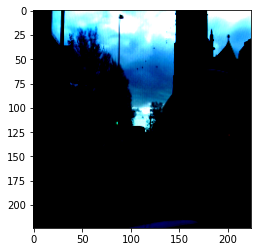

In [ ]:
plt.imshow(np.transpose(batch_x[0], (1, 2, 0)))

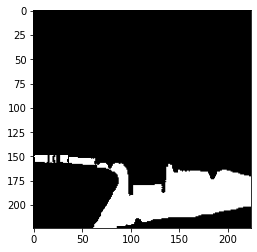

In [ ]:
plt.imshow(batch_y[0].squeeze(), cmap='gray')

In [ ]:
# Define data loaders

# Train dataloader
train_dataset = LaneDataset(
    x_train_dir, 
    y_train_dir, 
    transforms = Compose([Resize((224, 224)), ToTensor()]),
    preprocessing = True,
    training_type = 'train'
)

train_loader = DataLoader(
    train_dataset, 
    batch_size = 16,
    num_workers = 4
)

# Val dataloader
val_dataset = LaneDataset(
    x_val_dir, 
    y_val_dir, 
    transforms = Compose([Resize((224, 224)), ToTensor()]),
    preprocessing = True,
    training_type = 'val'
)

val_loader = DataLoader(
    val_dataset, 
    batch_size = 16,
    num_workers = 4
)

# Test dataloader
test_dataset = LaneDataset(
    x_test_dir, 
    transforms = Compose([Resize((224, 224)), ToTensor()]),
    preprocessing = True,
    training_type = 'test'
)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


# DEFINE MODEL ARCHITECHTURE

In [62]:
# create U-Net model with pretrained densenet
model = smp.Unet(
    encoder_name = 'densenet121', 
    encoder_weights = 'imagenet', 
    classes = 1, 
    activation = 'sigmoid',
)

Downloading: "http://data.lip6.fr/cadene/pretrainedmodels/densenet121-fbdb23505.pth" to /root/.cache/torch/hub/checkpoints/densenet121-fbdb23505.pth


In [63]:
# check for one iteration of loop
for batch_x, batch_y in train_loader:
    break

In [64]:
# check model on one image
model.eval()
output = model(batch_x[1].view(1, 3, 224, 224)).detach().numpy()

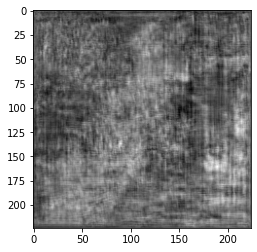

In [ ]:
# print output
plt.imshow(output.squeeze(), cmap='gray')

# TRAIN

In [ ]:
# define loss function
criterion = smp.utils.losses.DiceLoss()

# define optimizer
optimizer = torch.optim.Adam([parameters for parameters in model.parameters() if parameters.requires_grad], lr = 1e-3)

# define evaluation metric
metrics = [
    smp.utils.metrics.IoU(threshold = 0.5)
]

In [ ]:
train_epoch = smp.utils.train.TrainEpoch(
    model, 
    loss = criterion, 
    metrics = metrics, 
    optimizer = optimizer,
    device = 'cuda',
    verbose = True,
)

val_epoch = smp.utils.train.ValidEpoch(
    model, 
    loss = criterion, 
    metrics = metrics, 
    device = 'cuda',
    verbose = True,
)

In [ ]:
# saving best model
max_score = 0

for i in range(0, 15):
    print('\nEpoch: {}'.format(i + 1))
    train_logs = train_epoch.run(train_loader)
    val_logs = val_epoch.run(val_loader)
    
    if max_score < val_logs['iou_score']:
        max_score = val_logs['iou_score']
        torch.save(model, './best_model.pth')
        print('Model saved!')

    # decreasing lr to fine tune model
    if i+1 == 10:
        optimizer.param_groups[0]['lr'] = 1e-5
        print('Decrease learning rate to 1e-5')


Epoch: 1
train:   0%|          | 0/23 [00:00<?, ?it/s]

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


valid: 100%|██████████| 7/7 [00:28<00:00,  4.10s/it, dice_loss - 0.1405, iou_score - 0.852]
Model saved!

Epoch: 2
valid: 100%|██████████| 7/7 [00:01<00:00,  4.66it/s, dice_loss - 0.07622, iou_score - 0.8946]
Model saved!

Epoch: 3
valid: 100%|██████████| 7/7 [00:01<00:00,  4.74it/s, dice_loss - 0.0484, iou_score - 0.9312]
Model saved!

Epoch: 4
valid: 100%|██████████| 7/7 [00:01<00:00,  4.72it/s, dice_loss - 0.0886, iou_score - 0.8499]

Epoch: 5
valid: 100%|██████████| 7/7 [00:01<00:00,  4.53it/s, dice_loss - 0.7501, iou_score - 0.1528]

Epoch: 6
valid: 100%|██████████| 7/7 [00:01<00:00,  4.56it/s, dice_loss - 0.0308, iou_score - 0.9477]
Model saved!

Epoch: 7
valid: 100%|██████████| 7/7 [00:01<00:00,  4.74it/s, dice_loss - 0.03138, iou_score - 0.9444]

Epoch: 8
valid: 100%|██████████| 7/7 [00:01<00:00,  4.76it/s, dice_loss - 0.03794, iou_score - 0.9308]

Epoch: 9
valid: 100%|██████████| 7/7 [00:01<00:00,  4.56it/s, dice_loss - 0.1037, iou_score - 0.8184]

Epoch: 10
valid: 100%|██████

# IoU SCORE

In [ ]:
# load best saved checkpoint
model = torch.load('./best_model.pth')

In [ ]:
# get sample data
image = Image.open(dir + 'train/0006R0_f00930.png')
gt_mask = Image.open(dir + 'trainannot/0006R0_f00930.png')

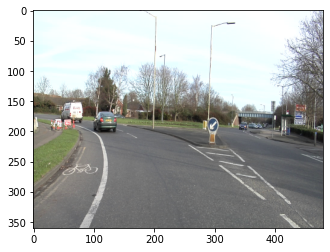

In [ ]:
plt.imshow(image)

In [ ]:
# preprocess mask
gt_mask = np.array(gt_mask)
gt_mask = (gt_mask == 3)
gt_mask = Image.fromarray(gt_mask)

# apply data augmentation
transform = Compose([Resize((224, 224)), ToTensor()])
image = transform(image)
image = Compose([Normalize(mean = [0.485, 0.456, 0.406],
                            std = [0.229, 0.224, 0.225])])(image)

gt_mask = transform(gt_mask)

In [ ]:
model.eval()
output = model(image.view(1, 3, 224, 224).to("cuda")).cpu().detach().numpy()

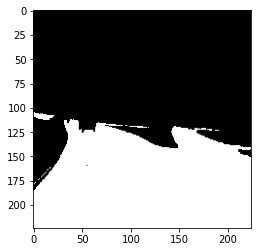

In [ ]:
plt.imshow(gt_mask.squeeze(), cmap='gray')

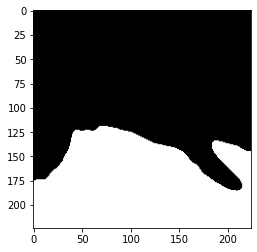

In [ ]:
plt.imshow((output.squeeze() > 0.5).astype(int), cmap='gray')

In [ ]:
# convert predicted mask to flattened numpy array
mask = (output.squeeze() > 0.5).astype(int)
pred = mask.ravel().copy()

# convert ground truth mask to flattened numpy array
gt_mask = gt_mask.cpu().detach().numpy()
target = gt_mask.ravel().copy().astype(int)

# get class indices for Lane
pred_inds = pred == 1
target_inds = target == 1

# calculate intersection
intersection = pred_inds[target_inds].sum()

# calculate union
union = pred_inds.sum() + target_inds.sum() - intersection

# get IoU score
iou = (float(intersection) / float(max(union, 1)))
iou

0.86688803164217

# INFERENCE ON TEST

In [ ]:
# run model for all images in test dataset
test_masks = []

model.eval()

with torch.no_grad():
    for test_image in test_dataset:
        mask = model(test_image.unsqueeze(0).to('cuda')).cpu().detach().numpy()
        test_masks.append(mask)

test_masks = (np.concatenate((test_masks), axis=0) > 0.5).astype(int)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


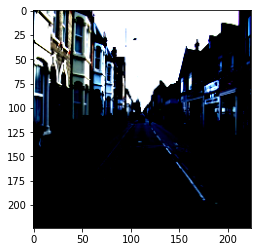

In [ ]:
# show original image
test_image = test_dataset[100]
plt.imshow(np.transpose(test_image, (1, 2, 0)))

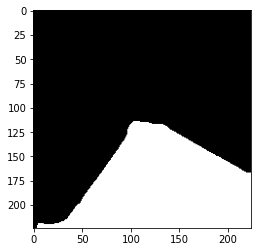

In [ ]:
# show prediction
plt.imshow((test_masks[100]).squeeze(), cmap='gray')